In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Banco de dados 1.xlsx')

df.head()

,Matrícula,Último Evento de Matrícula,Situação Matrícula,Curso
0,20181LI103,Cancelamento Compulsório: 13/09/2018,Cancelamento Compulsório,Licenciatura em Informática EAD
1,20141ENGME013,Cancelamento Compulsório: 29/05/2018,Cancelamento Compulsório,ENGENHARIA MECÂNICA
2,20112LI133,Cancelamento Voluntário: 17/10/2013,Cancelado,Licenciatura em Informática EAD
3,20112LI134,Cancelamento Voluntário: 23/01/2012,Cancelado,Licenciatura em Informática EAD
4,20112LI263,Cancelamento Voluntário: 23/08/2011,Cancelado,Licenciatura em Informática EAD


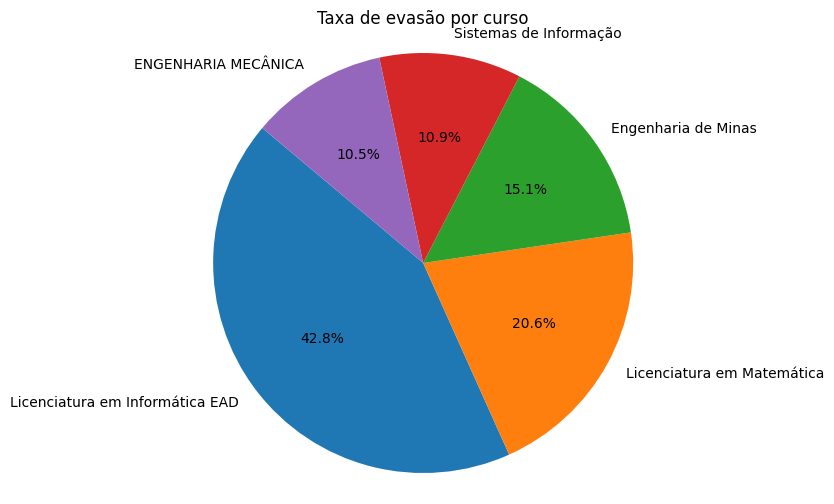

In [42]:
curso_counts = df['Curso'].value_counts()
porcentagens = (curso_counts / curso_counts.sum()) * 100


title = 'Taxa de evasão por curso'
plt.figure(figsize=(10, 6))
plt.pie(porcentagens, labels=porcentagens.index, autopct='%1.1f%%', startangle=140)
plt.title(title)
plt.axis('equal')
plt.savefig(f'{title}.png', dpi=300)
plt.show()

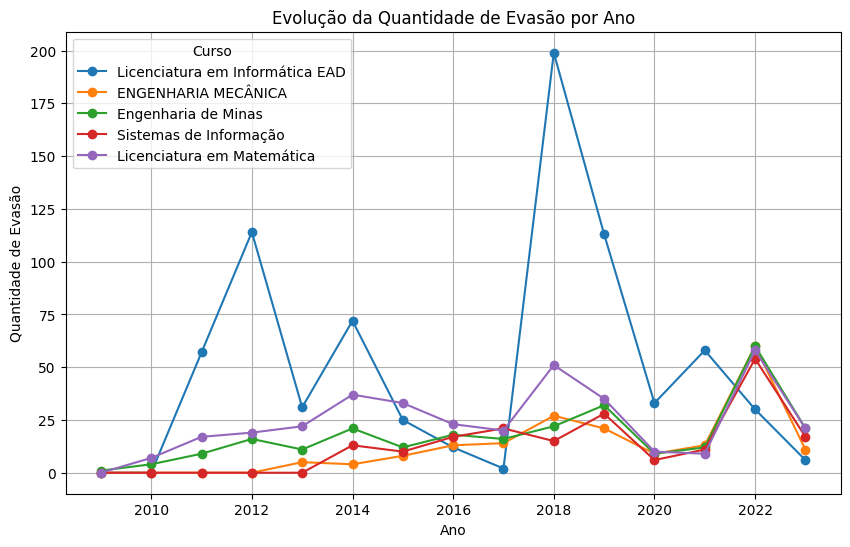

In [43]:
cursos_unicos = df['Curso'].unique()

# Extrair ano do último evento de matrícula
df['Ano'] = pd.to_datetime(df['Último Evento de Matrícula'].str.extract(r'(\d{2}/\d{2}/\d{4})')[0], format='%d/%m/%Y').dt.year

# Criar uma lista de todos os anos possíveis
todos_anos = range(int(df['Ano'].min()), int(df['Ano'].max()) + 1)

# Inicializar o dicionário para armazenar os cancelamentos por curso por ano
cancelamentos_por_curso_por_ano = {}

# Preencher o dicionário com todos os anos possíveis e definir os valores como 0
for curso in cursos_unicos:
    cancelamentos_por_curso_por_ano[curso] = pd.Series(0, index=todos_anos)

# Contar o número de cancelamentos por ano para cada curso
for curso in cursos_unicos:
    df_curso = df[df['Curso'] == curso]
    cancelamentos_por_curso_por_ano[curso] = df_curso['Ano'].value_counts().reindex(todos_anos, fill_value=0).sort_index()

# Plotar
plt.figure(figsize=(10, 6))
for curso, cancelamentos_por_ano in cancelamentos_por_curso_por_ano.items():
    cancelamentos_por_ano.plot(label=curso, marker='o')

title = 'Evolução da Quantidade de Evasão por Ano'
plt.title(title)
plt.xlabel('Ano')
plt.ylabel('Quantidade de Evasão')
plt.legend(title='Curso')
plt.grid(True)
plt.savefig(f'{title}.png', dpi=300)
plt.show()

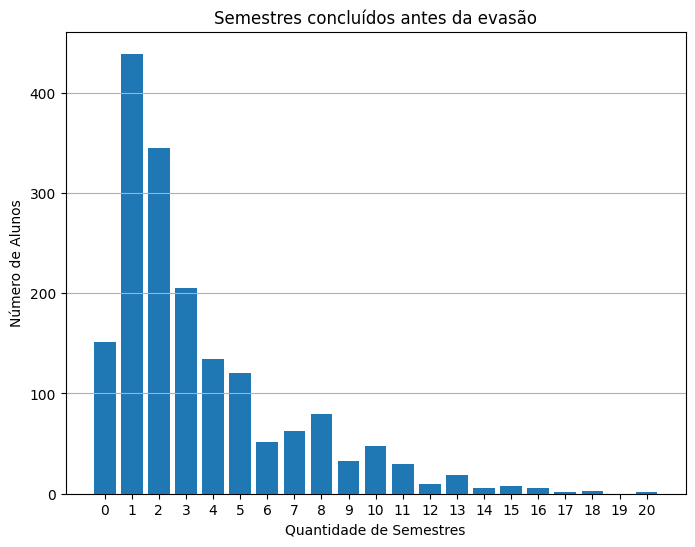

In [44]:
def calcular_quantidade_semestres(matricula, ultimo_evento):
    try:
        ano_matricula = int(matricula[:4])
        semestre_matricula = int(matricula[4]) 
        ano_ultimo_evento = int(ultimo_evento[-4:])
        semestre_ultimo_evento = int(ultimo_evento[-7:-5])
        semestres = (ano_ultimo_evento - ano_matricula) * 2
        if semestre_ultimo_evento > 6 and semestre_matricula == 1: semestres += 1
        elif semestre_ultimo_evento <= 6 and semestre_matricula == 2: semestres -= 1
        return semestres
    except Exception:
        return False

# Aplicar a função para calcular a quantidade de semestres para cada linha
df['Quantidade Semestres'] = df.apply(lambda row: calcular_quantidade_semestres(row['Matrícula'], row['Último Evento de Matrícula']), axis=1)

title = 'Semestres concluídos antes da evasão'
plt.figure(figsize=(8, 6))
plt.hist(df['Quantidade Semestres'], bins=range(df['Quantidade Semestres'].min(), df['Quantidade Semestres'].max() + 2), align='left', rwidth=0.8)
plt.title(title)
plt.xlabel('Quantidade de Semestres')
plt.ylabel('Número de Alunos')
plt.xticks(range(df['Quantidade Semestres'].min(), df['Quantidade Semestres'].max() + 1))
plt.grid(axis='y')
plt.savefig(f'{title}.png', dpi=300)
plt.show()